# Spidroin Protein Sequence Confirmation

End-to-end pipeline that builds on `typing_results/` to:

1. Align NCBI full-length spidroin proteins to each spidroin locus with miniprot (splice-aware)
2. Translate the predicted CDS and run pairwise alignment vs the matched NCBI protein
3. Validate predictions through 5 orthogonal evidence dimensions (pairwise / DIAMOND / hmmscan / motif / length)
4. Build per-protein domain-level multiple sequence alignments (strict + loose panels)
5. Refine gene structures with Augustus using miniprot CDS as hints
6. Cross-check intron boundaries with RNA-seq splice junctions
7. Emit a cross-species summary and 5 presentation figures

Conventions
- Intermediate artifacts (indexes, raw tool outputs) → `data/interim/<task_name>/`
- Final products (per-spidroin GFF / TSV / MSA / figures) → `data/processed/<task_name>/`
- Figures → `reports/figures/<task_name>/`

## Environment Setup
```bash
pixi install
```

## Step 0: Configuration

Single source of truth for paths.  Change `task_name` if you want a clean run.

In [ ]:
from pathlib import Path

from spider_silkome_module import (
    EXTERNAL_DATA_DIR,
    FIGURES_DIR,
    INTERIM_DATA_DIR,
    PROCESSED_DATA_DIR,
)
from spider_silkome_module.utils.run_cmd import run_cmd

In [ ]:
task_name = "protein_confirmation_20260521"

# === Inputs ===
fullprot_fasta = EXTERNAL_DATA_DIR / "spidroins_full_length_with_dataset1.fasta"
typing_results_dir = PROCESSED_DATA_DIR / "typing_results"
silkome_prot = EXTERNAL_DATA_DIR / "spider-silkome-database.v1.prot.fixed.renamed.fasta"
silkome_ntd_ctd_dir = INTERIM_DATA_DIR / "spidroin_proteins"
existing_protein_hmm_dir = INTERIM_DATA_DIR / "spider_silkome_20251222" / "hmmbuild_output"
extrinsic_cfg = EXTERNAL_DATA_DIR / "extrinsic.cfg"
augustus_species = "parasteatoda"
bam_root = INTERIM_DATA_DIR.parent / "raw" / "Spider_anno"  # data/raw/Spider_anno

# === Intermediate outputs (INTERIM) ===
interim_dir = INTERIM_DATA_DIR / task_name
cdhit_dir = interim_dir / "cdhit"
cdhit_rep_seq = cdhit_dir / "cdhit_rep_seq.fa"
cdhit_shortest = cdhit_dir / "cdhit_shortest_seq.fa"

hmm_lib_dir = interim_dir / "hmm_library"
all_domains_hmm = hmm_lib_dir / "all_domains.hmm"

diamond_db_dir = interim_dir / "diamond_db"
diamond_db = diamond_db_dir / "silkome.dmnd"

mpi_dir = interim_dir / "mpi"
miniprot_raw_dir = interim_dir / "miniprot_raw"
augustus_hints_dir = interim_dir / "augustus_hints"

# === Final outputs (PROCESSED) ===
output_dir = PROCESSED_DATA_DIR / task_name
confirmation_dir = output_dir / "confirmation"
msa_dir = output_dir / "msa"
augustus_dir = output_dir / "augustus"
rna_junction_dir = output_dir / "rna_junction"
summary_tsv = output_dir / "summary_all_species.tsv"

# === Figures ===
figures_dir = FIGURES_DIR / task_name

# Threads
threads = 70

## Step 1: Input Preprocessing  (→ INTERIM)

1.1 De-duplicate `spidroins_full_length_with_dataset1.fasta` with cd-hit, then pick the shortest representative per cluster (consistent with `miniprot_mapping.ipynb`).

1.2 Concatenate the per-type protein HMMs into a single `all_domains.hmm` and `hmmpress` it for `hmmscan`.

1.3 Build a DIAMOND blastp database from the silkome protein library.

In [ ]:
# 1.1 cd-hit dedup
run_cmd(
    f"pixi run cd-hit -i {fullprot_fasta} -o {cdhit_rep_seq} -c 0.9 -T 0 -M 0 -d 0",
    [cdhit_rep_seq],
)

run_cmd(
    f"pixi run python -m spider_silkome_module.extract_shortest_seq "
    f"--clstr-path {cdhit_rep_seq}.clstr "
    f"--fasta-path {fullprot_fasta} "
    f"--output-path {cdhit_shortest}",
    [cdhit_shortest],
)

In [ ]:
# 1.2 cat per-type protein HMMs into all_domains.hmm + hmmpress
run_cmd(
    f"mkdir -p {hmm_lib_dir} && cat {existing_protein_hmm_dir}/*.hmm > {all_domains_hmm} && "
    f"hmmpress -f {all_domains_hmm}",
    [all_domains_hmm, Path(str(all_domains_hmm) + '.h3i')],
)

In [ ]:
# 1.3 DIAMOND db from silkome protein library
run_cmd(
    f"mkdir -p {diamond_db_dir} && "
    f"diamond makedb --in {silkome_prot} -d {diamond_db}",
    [diamond_db],
)

## Step 2: Build mpi indexes from typing_results  (→ INTERIM)

One `.mpi` index per species, built from `typing_results/<species>/spidroin_full_length.fasta`.

In [ ]:
run_cmd(
    f"pixi run python -m spider_silkome_module.build_typing_mpi "
    f"--typing-dir {typing_results_dir} "
    f"--output-path {mpi_dir} "
    f"--threads {threads}",
    [mpi_dir],
)

## Step 3: Miniprot Full-Length Alignment  (→ INTERIM/miniprot_raw)

Splice-aware alignment of NCBI full-length spidroin proteins to each species' spidroin locus DNA.

Parameters:
- `--max-intron 50000`  cap intron length to 50 kb
- `--outs 0.95`         filter low-fraction hits (best vs 2nd best)
- `--outc 0.5`          require ≥50% query coverage

In [ ]:
run_cmd(
    f"pixi run python -m spider_silkome_module.run_miniprot "
    f"--mpi-input-path {mpi_dir} "
    f"--protein-fasta {cdhit_shortest} "
    f"--output-path {miniprot_raw_dir} "
    f"--max-intron 50000 --outs 0.95 --outc 0.5 "
    f"--threads {threads}",
    [miniprot_raw_dir],
)

In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

def parse_attrs(s):
    out = {}
    for item in s.split(";"):
        if "=" in item:
            k, v = item.split("=", 1)
            out[k] = v
    return out

def load_miniprot_records(gff_path):
    records = {}
    with open(gff_path) as fh:
        for line in fh:
            if line.startswith("#") or not line.strip():
                continue
            seqid, source, feature, start, end, score, strand, phase, attrs_s = line.rstrip().split("\t")[:9]
            attrs = parse_attrs(attrs_s)
            start, end = int(start), int(end)
            score = float(score) if score != "." else 0.0

            if feature == "mRNA":
                target = attrs.get("Target", "").split()
                rec_id = attrs["ID"]
                records[rec_id] = {
                    "id": rec_id,
                    "seqid": seqid,
                    "start": start,
                    "end": end,
                    "score": score,
                    "strand": strand,
                    "rank": attrs.get("Rank", ""),
                    "identity": float(attrs.get("Identity", 0)),
                    "positive": float(attrs.get("Positive", 0)),
                    "query": target[0] if target else "",
                    "target_from": target[1] if len(target) > 1 else "",
                    "target_to": target[2] if len(target) > 2 else "",
                    "frameshift": attrs.get("Frameshift", ""),
                    "stopcodon": attrs.get("StopCodon", ""),
                    "cds": [],
                }
            elif feature == "CDS":
                parent = attrs.get("Parent")
                if parent in records:
                    records[parent]["cds"].append((start, end))
    return list(records.values())

def plot_miniprot_hits(gff_path, spidroin_id, top_n=30):
    hits = [r for r in load_miniprot_records(gff_path) if r["seqid"] == spidroin_id]
    hits = sorted(hits, key=lambda r: (r["score"], r["identity"]), reverse=True)[:top_n]

    fig, ax = plt.subplots(figsize=(14, max(3, 0.38 * len(hits) + 1)))

    for y, r in enumerate(hits):
        ax.hlines(y, r["start"], r["end"], color="#999", linewidth=1)
        for s, e in r["cds"]:
            ax.add_patch(Rectangle((s, y - 0.16), e - s + 1, 0.32, color="#2563eb", alpha=0.85))

        label = (
            f'{r["query"]}  aa:{r["target_from"]}-{r["target_to"]}  '
            f'id={r["identity"]:.2f}  score={r["score"]:.0f}  rank={r["rank"]}'
        )
        if r["frameshift"]:
            label += f'  frameshift={r["frameshift"]}'
        if r["stopcodon"]:
            label += f'  stop={r["stopcodon"]}'

        ax.text(r["end"] + 80, y, label, va="center", fontsize=8)

    ax.set_yticks(range(len(hits)))
    ax.set_yticklabels([h["id"] for h in hits], fontsize=7)
    ax.invert_yaxis()
    ax.set_xlabel(f"Position on {spidroin_id} sequence (bp)")
    ax.set_title(f"miniprot hits on {spidroin_id}")
    ax.grid(axis="x", alpha=0.2)
    plt.tight_layout()
    return fig, ax

(<Figure size 1400x1240 with 1 Axes>,
 <Axes: title={'center': 'miniprot hits on Aldi_spid_00021'}, xlabel='Position on Aldi_spid_00021 sequence (bp)'>)

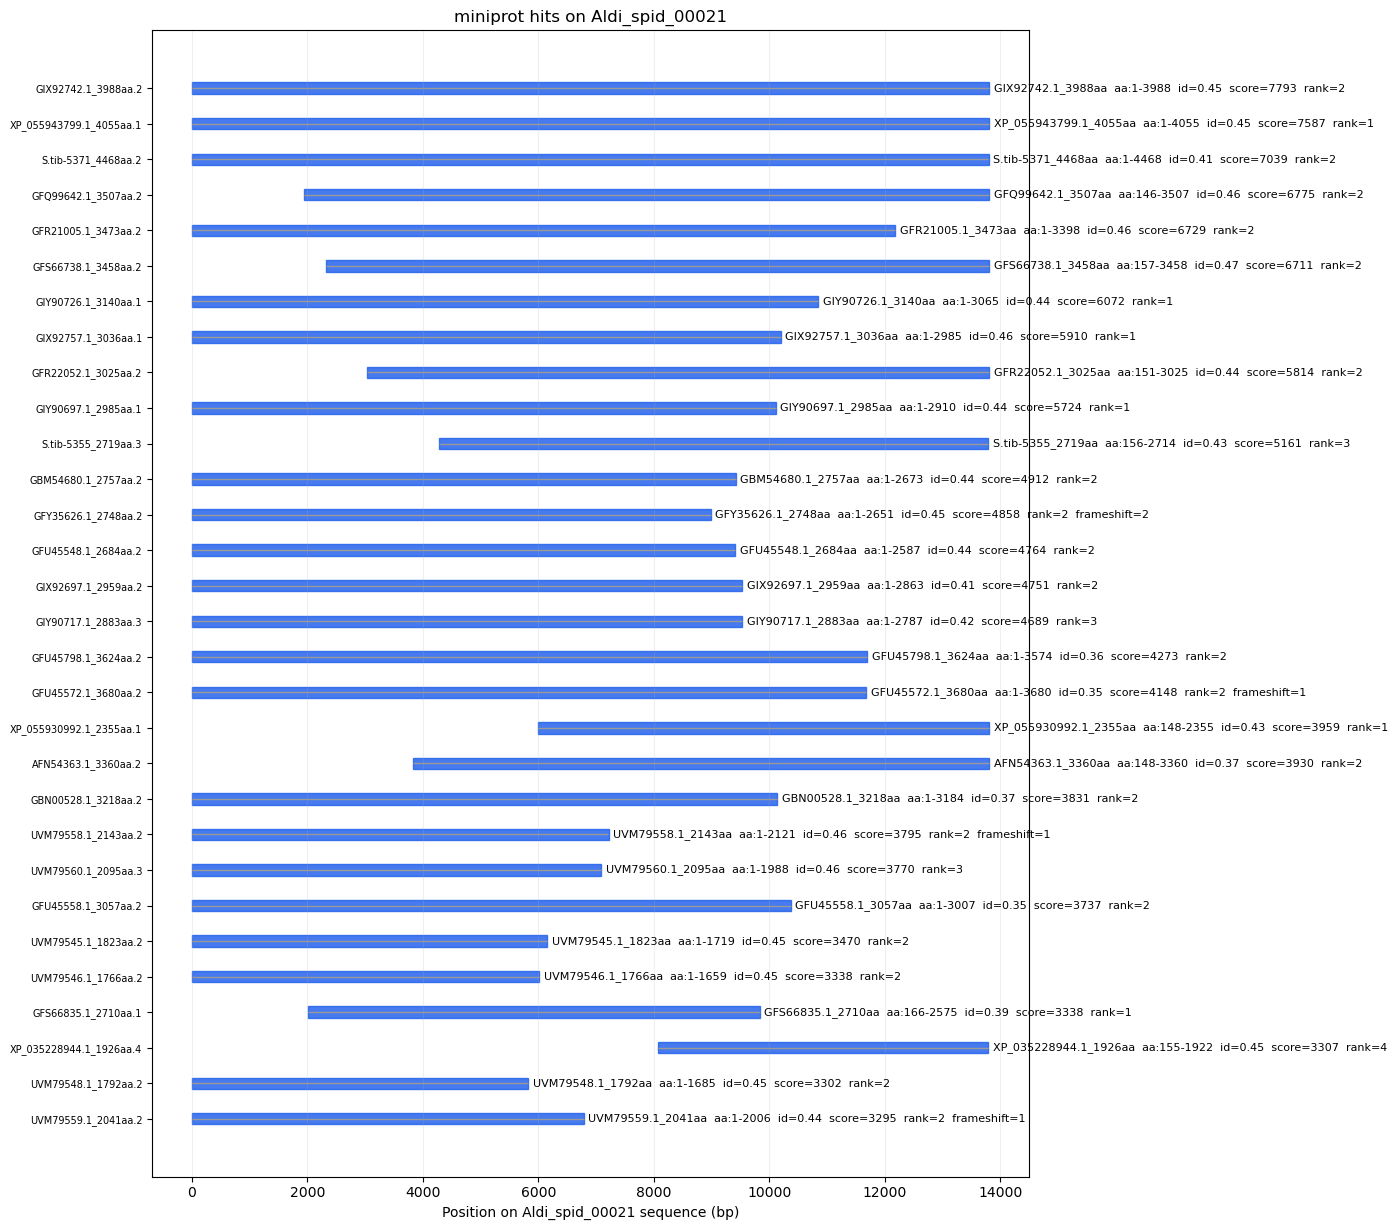

In [12]:
gff = Path(f"{miniprot_raw_dir}/001.Allagelena_difficilis.gff")
plot_miniprot_hits(gff, "Aldi_spid_00021", top_n=30)

## Step 4: Confirmation + Multi-Evidence Validation  (→ PROCESSED/confirmation)

Two sub-steps:

4.1 `protein_confirmation`: parse miniprot GFF → translate predicted CDS → pairwise alignment vs the matched NCBI protein (dimension **A**).  Writes `predicted_proteins.fa`, `fullprot_miniprot.gff`, `pairwise_vs_ncbi.tsv` per species.

4.2 `protein_validation`: run DIAMOND blastp vs silkome (B), hmmscan vs `all_domains.hmm` (C), conserved-motif checks (D), and within-type length z-score (E).  Emits per-dimension TSVs plus the combined `protein_confirmation.tsv` with `validation_score` and `validation_status`.

In [ ]:
run_cmd(
    f"pixi run python -m spider_silkome_module.protein_confirmation "
    f"--miniprot-raw-dir {miniprot_raw_dir} "
    f"--typing-dir {typing_results_dir} "
    f"--query-fasta {cdhit_shortest} "
    f"--output-dir {confirmation_dir}",
    [confirmation_dir],
)

In [ ]:
run_cmd(
    f"pixi run python -m spider_silkome_module.protein_validation "
    f"--confirmation-dir {confirmation_dir} "
    f"--typing-dir {typing_results_dir} "
    f"--diamond-db {diamond_db} "
    f"--hmm-db {all_domains_hmm} "
    f"--threads {threads}",
    [confirmation_dir],
    force=True,
)

## Step 5: Per-Protein Domain-Level MSA  (→ PROCESSED/msa)

For each predicted protein:
- NTD vs same-type panel (`ntd_strict.aln`) and same-family-group panel (`ntd_loose.aln`)
- CTD vs same-type panel (`ctd_strict.aln`) and same-family-group panel (`ctd_loose.aln`)
- Full-length predicted vs same-type panel (`overview.aln`)

MAFFT L-INS-i (`--localpair --maxiterate 1000`) is used for the domain panels because spidroin NTD/CTD are short and locally conserved.  TrimAl `-gappyout` removes gap-heavy columns.

By default only `validated`+`partial` predictions are processed; set `--no-only-validated` to run on all.

In [ ]:
run_cmd(
    f"pixi run python -m spider_silkome_module.per_protein_msa "
    f"--confirmation-dir {confirmation_dir} "
    f"--msa-dir {msa_dir} "
    f"--ref-dir {silkome_ntd_ctd_dir} "
    f"--threads {threads}",
    [msa_dir],force=True
)

## Step 6: Augustus Refinement with miniprot hints  (→ PROCESSED/augustus)

Convert miniprot CDS rows into strong P (protein) hints (`start`, `stop`, `exonpart`, `intron`) and run Augustus on each `spidroin_full_length.fasta`.

In [ ]:
run_cmd(
    f"pixi run python -m spider_silkome_module.augustus_with_miniprot_hints "
    f"--miniprot-raw-dir {miniprot_raw_dir} "
    f"--typing-dir {typing_results_dir} "
    f"--hints-dir {augustus_hints_dir} "
    f"--output-dir {augustus_dir} "
    f"--extrinsic-cfg {extrinsic_cfg} "
    f"--augustus-species {augustus_species}",
    [augustus_dir],
)

## Step 7: RNA-seq Splice Junction Validation  (→ PROCESSED/rna_junction)

Walk each species' RNA-seq BAM (`data/raw/Spider_anno/<species>/outs/sorted.bam`), extract junctions from `N` CIGAR operations within each spidroin gene window, and check whether predicted intron boundaries match RNA-seq junctions within ±3 bp.

In [ ]:
run_cmd(
    f"pixi run python -m agents.evidence.junction_validation "
    f"--confirmation-dir {confirmation_dir} "
    f"--typing-dir {typing_results_dir} "
    f"--bam-root {bam_root} "
    f"--output-dir {rna_junction_dir}",
    [rna_junction_dir],
)

## Step 8: Cross-Species Summary  (→ PROCESSED/summary_all_species.tsv)

Concatenate all per-species `protein_confirmation.tsv` files and (when available) join the RNA-seq intron validation.  The summary is the input for Step 9 figures and the final hand-off to downstream review.

In [ ]:
import polars as pl

SUMMARY_SCHEMA_OVERRIDES = {
    "miniprot_score": pl.Int64,
    "miniprot_identity": pl.Float64,
    "pairwise_identity": pl.Float64,
    "pairwise_coverage_query": pl.Float64,
    "pairwise_coverage_target": pl.Float64,
    "predicted_protein_length": pl.Int64,
    "ref_protein_length": pl.Int64,
    "exon_count": pl.Int64,
    "intron_count": pl.Int64,
    "total_intron_len": pl.Int64,
    "has_premature_stop": pl.Boolean,
    "miniprot_has_start": pl.Boolean,
    "miniprot_has_stop": pl.Boolean,
    "mrna_start": pl.Int64,
    "mrna_end": pl.Int64,
    "full_length": pl.Boolean,
    "diamond_pident": pl.Float64,
    "diamond_length": pl.Int64,
    "diamond_evalue": pl.Float64,
    "diamond_bitscore": pl.Float64,
    "hmm_ntd_evalue": pl.Float64,
    "hmm_ntd_from": pl.Int64,
    "hmm_ntd_to": pl.Int64,
    "hmm_ctd_evalue": pl.Float64,
    "hmm_ctd_from": pl.Int64,
    "hmm_ctd_to": pl.Int64,
    "hmm_domain_order_correct": pl.Boolean,
    "has_signal_peptide_motif": pl.Boolean,
    "has_ctd_cysteines": pl.Boolean,
    "length_zscore_within_type": pl.Float64,
    "length_outlier": pl.Boolean,
    "validation_score": pl.Float64,
}

INTRON_SCHEMA_OVERRIDES = {
    "n_introns_predicted": pl.Int64,
    "n_introns_rnaseq_supported": pl.Int64,
    "junction_support_rate": pl.Float64,
    "min_junction_depth": pl.Float64,
    "median_junction_depth": pl.Float64,
}

frames = []
for sp_dir in sorted(confirmation_dir.iterdir()):
    if not sp_dir.is_dir():
        continue
    tsv = sp_dir / "protein_confirmation.tsv"
    if not tsv.exists():
        continue
    df_sp = pl.read_csv(
        tsv,
        separator="\t",
        infer_schema_length=2000,
        schema_overrides=SUMMARY_SCHEMA_OVERRIDES,
        null_values=[""],
    )
    # Optional intron support join.
    intron_tsv = rna_junction_dir / sp_dir.name / "intron_validation.tsv"
    if intron_tsv.exists():
        intron_df = pl.read_csv(
            intron_tsv,
            separator="\t",
            infer_schema_length=200,
            schema_overrides=INTRON_SCHEMA_OVERRIDES,
            null_values=[""],
        )
        df_sp = df_sp.join(intron_df, on="spidroin_id", how="left")
    frames.append(df_sp)

summary = pl.concat(frames, how="diagonal") if frames else pl.DataFrame()
summary_tsv.parent.mkdir(parents=True, exist_ok=True)
summary.write_csv(summary_tsv, separator="\t")
print(f"Wrote {summary_tsv}  ({summary.shape})")
summary.head()


## Step 9: Presentation Figures  (→ reports/figures/<task_name>/)

Five publication-ready figures, each saved as both PNG (slides) and SVG (poster/paper).

1. `pipeline_funnel` — number of loci surviving each filter
2. `validation_score_by_type` — boxplot of validation_score per spidroin type
3. `identity_vs_coverage` — pairwise identity × coverage scatter, coloured by status
4. `species_type_heatmap` — validated count per species × type
5. `gene_structure_examples` — representative gene tracks per type

In [ ]:
run_cmd(
    f"pixi run python -m spider_silkome_module.plot_protein_confirmation all "
    f"--summary-tsv {summary_tsv} "
    f"--confirmation-dir {confirmation_dir} "
    f"--output-dir {figures_dir}",
    [figures_dir],
    force=True,
)

from IPython.display import Image, display
for stem in (
    "pipeline_funnel",
    "validation_score_by_type",
    "identity_vs_coverage",
    "species_type_heatmap",
    "gene_structure_examples",
):
    p = figures_dir / f"{stem}.png"
    if p.exists():
        print(stem)
        display(Image(filename=str(p)))